# Lecture 21: XGBoost, Feature Importance & SHAP

**F&W ECOL 458 — Environmental Data Science**

Reference: [XGBoost documentation](https://xgboost.readthedocs.io/) | [SHAP documentation](https://shap.readthedocs.io/)

---

### Learning objectives

1. Explain how gradient boosting differs from bagging (random forests).
2. Train an XGBoost model and tune its key hyperparameters.
3. Compare Random Forest and XGBoost on the shortwave radiation prediction task from Lecture 20.
4. Compute and interpret three types of feature importance: Gini, permutation, and SHAP.
5. Read and interpret SHAP summary plots, dependence plots, and force plots.
6. Choose the right algorithm and importance method for a given problem.


## 1. Two Philosophies of Ensemble Learning

Last lecture we learned that combining many decision trees into a **random forest** reduces overfitting through **bagging**. Today we introduce a fundamentally different ensemble strategy called **boosting**.

### Bagging (Random Forest) — "Ask many independent experts"

Imagine you need to estimate the temperature tomorrow. You ask 100 meteorologists *independently* — none of them knows what the others predicted. Then you average their answers. Some are too high, some too low, but the average is remarkably accurate because individual errors cancel out.

This is bagging:
- Train many trees **independently** on random bootstrap samples.
- Each tree is a full-strength learner (deep tree).
- Combine by **majority vote** (classification) or **averaging** (regression).
- Goal: **reduce variance** — smooth out the noise of individual trees.

### Boosting (XGBoost) — "Learn from your mistakes"

Now imagine a different strategy. One student takes an exam and gets 70%. Instead of starting over, they study *specifically the questions they got wrong*, retake the exam, and improve to 80%. They study the remaining mistakes, retake again, and reach 90%. Each round focuses on the residual errors from the previous round.

This is boosting:
- Train trees **sequentially** — each new tree focuses on the mistakes of the previous ensemble.
- Each tree is a **weak learner** (small, shallow tree — typically depth 3-6).
- Combine by **weighted sum** — each tree adds a small correction.
- Goal: **reduce bias** — iteratively correct systematic errors.

### Side-by-side comparison

| | Bagging (Random Forest) | Boosting (XGBoost) |
|---|---|---|
| Tree training | Independent, parallel | Sequential, each fixes prior errors |
| Tree depth | Deep (full trees) | Shallow (depth 3-6) |
| Number of trees | 100-500 | 100-1000+ |
| Main benefit | Reduces variance | Reduces bias |
| Overfitting risk | Low (hard to overfit) | Higher (can overfit if too many rounds) |
| Speed | Fast (parallelizable) | Slower (inherently sequential) |
| Typical accuracy | Very good | Often slightly better |


## 2. How XGBoost Works

**XGBoost** stands for e**X**treme **G**radient **Boost**ing. Let me walk through the algorithm step by step using our shortwave radiation example.

### The algorithm

Suppose we want to predict total shortwave radiation (SW) from atmospheric variables. Here is what XGBoost does:

**Round 0 — Start with a simple prediction.** Predict the average SW for every sample. For example, if the average SW in the training data is 350 W/m$^2$, every sample gets the prediction 350. This is our baseline — obviously crude, but it's a starting point.

**Round 1 — Compute residuals.** For each training sample, compute how wrong the current prediction is:

$$
\text{residual}_i = y_i - \hat{y}_i^{(0)}
$$

If the true SW for sample $i$ is 600 W/m$^2$ and our prediction is 350, the residual is +250. If the true value is 100, the residual is -250.

**Round 1 — Fit a small tree to the residuals.** Train a shallow decision tree (e.g., depth 4) that predicts these residuals from the input features. This tree learns patterns like: "when SZA is low and CLD_FRAC is low, the residual is large and positive" (i.e., the current model is underestimating SW for clear, high-sun conditions).

**Round 1 — Update the ensemble.** Add this tree to the model with a small **learning rate** $\eta$ (e.g., 0.1):

$$
\hat{y}_i^{(1)} = \hat{y}_i^{(0)} + \eta \cdot \text{tree}_1(\mathbf{x}_i)
$$

The learning rate shrinks the contribution of each tree so we don't overshoot. Without it, the model would try to correct all errors in one step and overfit.

**Round 2 — Repeat.** Compute new residuals: $\text{residual}_i = y_i - \hat{y}_i^{(1)}$. These residuals are smaller than before because the first correction tree already fixed the biggest errors. Fit another small tree to these new, smaller residuals. Add it to the ensemble.

**Round 3, 4, ..., $T$ — Keep going.** Each round adds a tree that fixes the remaining errors. After $T$ rounds:

$$
\hat{y}_i^{(T)} = \hat{y}_i^{(0)} + \eta \sum_{t=1}^{T} \text{tree}_t(\mathbf{x}_i)
$$

The name "gradient boosting" comes from the fact that fitting trees to residuals is mathematically equivalent to doing **gradient descent** in function space — each tree takes a step in the direction that most reduces the loss function.

### What makes XGBoost "extreme"?

XGBoost adds several optimizations beyond basic gradient boosting:

- **Regularization** (L1 and L2 penalties on tree complexity) to prevent overfitting — this is a major advantage over older gradient boosting implementations.
- **Efficient handling of missing values** — the algorithm learns which branch to send missing values to.
- **Parallel split search** — even though trees are trained sequentially, the search for the best split within each tree is parallelized.
- **Built-in cross-validation and early stopping** — stop adding trees when validation performance stops improving.


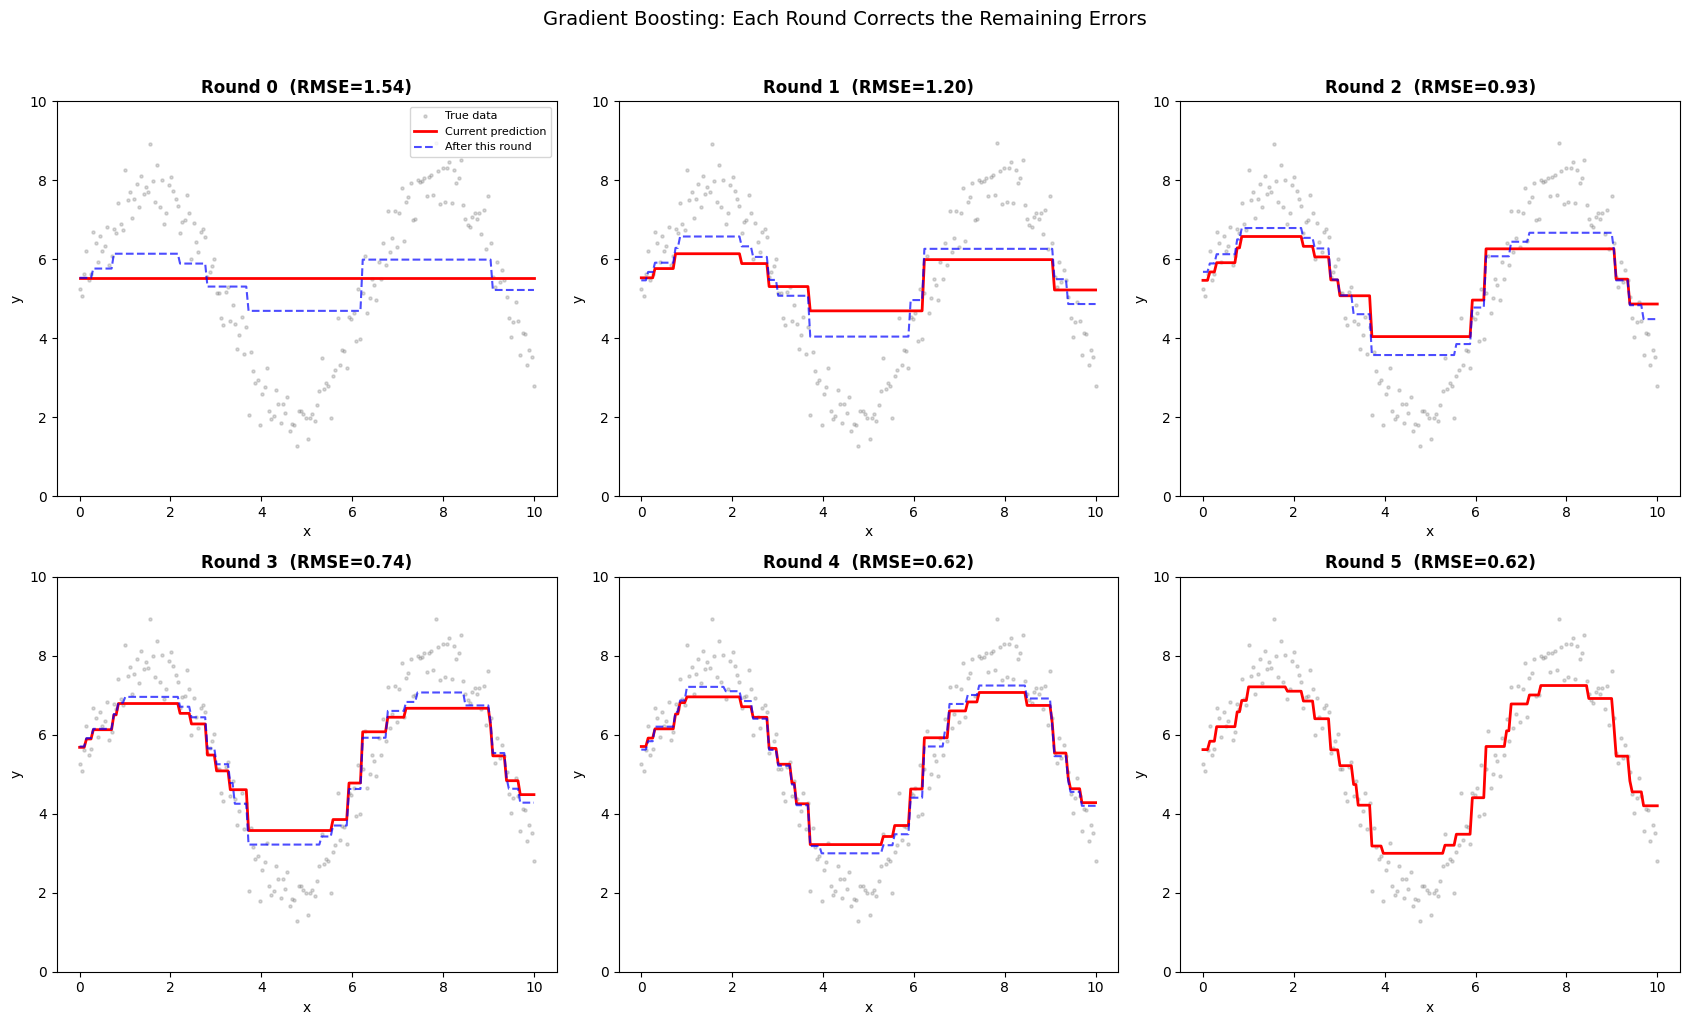

In [ ]:
# ── Visualize the boosting process conceptually ──
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.linspace(0, 10, 200)
y_true = np.sin(x) * 3 + 5
y_noise = y_true + np.random.normal(0, 0.5, len(x))

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Simulate boosting rounds
prediction = np.full_like(x, y_noise.mean())  # Round 0: predict the mean
eta = 0.3

for round_num, ax in enumerate(axes.flat):
    residuals = y_noise - prediction

    ax.scatter(x, y_noise, s=5, alpha=0.3, color='gray', label='True data')
    ax.plot(x, prediction, 'r-', linewidth=2, label='Current prediction')

    if round_num < 5:
        # Fit a simple tree to residuals (simulate with a coarse step function)
        from sklearn.tree import DecisionTreeRegressor
        tree = DecisionTreeRegressor(max_depth=3).fit(x.reshape(-1, 1), residuals)
        correction = tree.predict(x.reshape(-1, 1))
        ax.plot(x, prediction + eta * correction, 'b--', linewidth=1.5,
                alpha=0.7, label='After this round')
        prediction = prediction + eta * correction

    rmse = np.sqrt(np.mean((y_noise - prediction)**2))
    ax.set_title(f'Round {round_num}  (RMSE={rmse:.2f})', fontweight='bold')
    ax.set_ylim(0, 10)
    if round_num == 0:
        ax.legend(fontsize=8, loc='upper right')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Gradient Boosting: Each Round Corrects the Remaining Errors',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In Round 0, the model just predicts the mean (red line) — a terrible fit. Each subsequent round adds a small correction tree that bends the prediction closer to the true data. By Round 5, the model closely tracks the sinusoidal pattern.

Notice that **each individual correction is small** (controlled by the learning rate $\eta = 0.3$). This is intentional — small steps prevent overshooting and improve generalization.


## 3. XGBoost in Python

### Key hyperparameters

Before training, let's understand the hyperparameters you'll need to set:

| Parameter | What it controls | Typical range | Analogy |
|---|---|---|---|
| `n_estimators` | Number of boosting rounds (trees) | 100-1000 | How many exam retakes |
| `max_depth` | Depth of each individual tree | 3-8 | How detailed each correction is |
| `learning_rate` ($\eta$) | Step size for each correction | 0.01-0.3 | How cautiously you correct |
| `subsample` | Fraction of samples per tree | 0.5-1.0 | Like bagging within boosting |
| `colsample_bytree` | Fraction of features per tree | 0.5-1.0 | Like RF's random feature subsets |
| `reg_alpha` (L1) | Lasso-type regularization | 0-10 | Encourages sparse trees |
| `reg_lambda` (L2) | Ridge-type regularization | 0-10 | Penalizes large leaf values |

The most important tradeoff: **`n_estimators` vs. `learning_rate`**. A small learning rate needs many rounds but generalizes better. A large learning rate converges faster but risks overfitting. The standard approach is to set a small learning rate (0.05-0.1) and use **early stopping** to find the right number of rounds automatically.


## 4. Application: Random Forest vs. XGBoost on Shortwave Radiation

Let's continue with the shortwave radiation prediction task from Lecture 20 and compare Random Forest to XGBoost head-to-head.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load or generate SW radiation data ──
# Replace with: df = pd.read_csv('SW.csv') when using real data
np.random.seed(42)
n = 5000

SZA = np.random.uniform(0, 85, n)
AOD = np.random.exponential(0.15, n)
COD = np.random.exponential(5, n)
CLD_FRAC = np.random.uniform(0, 1, n)
UW = np.random.uniform(0.5, 5, n)
TO3 = np.random.uniform(250, 450, n)
Pressure = np.random.uniform(850, 1050, n)
BSA = np.random.uniform(0.05, 0.4, n)
WSA = np.random.uniform(0.05, 0.4, n)

cos_sza = np.cos(np.radians(SZA))
SW_direct = np.maximum(0, 1361 * cos_sza * np.exp(-AOD / np.clip(cos_sza, 0.05, 1))
                       * (1 - CLD_FRAC * 0.9) + np.random.normal(0, 15, n))
SW_diffuse = np.maximum(0, 200 * cos_sza * (0.3 + 0.5 * CLD_FRAC + 0.3 * AOD)
                        + np.random.normal(0, 10, n))

df = pd.DataFrame({
    'SZA': SZA, 'AOD': AOD, 'COD': COD, 'CLD_FRAC': CLD_FRAC,
    'UW': UW, 'TO3': TO3, 'Pressure': Pressure, 'BSA': BSA, 'WSA': WSA,
    'SW_direct': SW_direct, 'SW_diffuse': SW_diffuse
})
df['SW'] = df['SW_direct'] + df['SW_diffuse']

feature_cols = ['SZA', 'AOD', 'COD', 'CLD_FRAC', 'UW', 'TO3', 'Pressure', 'BSA', 'WSA']

print(f"Dataset: {len(df)} samples, {len(feature_cols)} features")
print(f"Targets: SW_direct, SW_diffuse, SW (total)")


Dataset: 5000 samples, 9 features
Targets: SW_direct, SW_diffuse, SW (total)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import time

X = df[feature_cols].values
y_total = df['SW'].values
y_direct = df['SW_direct'].values
y_diffuse = df['SW_diffuse'].values

X_train, X_test, yt_train, yt_test, yd_train, yd_test, yf_train, yf_test = (
    train_test_split(X, y_total, y_direct, y_diffuse,
                     test_size=0.25, random_state=42)
)

# ── Train both models on total SW ──
# Random Forest
t0 = time.time()
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, yt_train)
rf_time = time.time() - t0
rf_r2 = r2_score(yt_test, rf.predict(X_test))
rf_rmse = np.sqrt(mean_squared_error(yt_test, rf.predict(X_test)))

# XGBoost
t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, yt_train,
              eval_set=[(X_test, yt_test)],
              verbose=False)
xgb_time = time.time() - t0
xgb_r2 = r2_score(yt_test, xgb_model.predict(X_test))
xgb_rmse = np.sqrt(mean_squared_error(yt_test, xgb_model.predict(X_test)))

print(f"{'Model':<20s}  {'Test R2':>10s}  {'RMSE (W/m2)':>12s}  {'Train time':>12s}")
print("-" * 58)
print(f"{'Random Forest':<20s}  {rf_r2:>10.4f}  {rf_rmse:>12.1f}  {rf_time:>11.2f}s")
print(f"{'XGBoost':<20s}  {xgb_r2:>10.4f}  {xgb_rmse:>12.1f}  {xgb_time:>11.2f}s")


Model                    Test R2   RMSE (W/m2)    Train time
----------------------------------------------------------
Random Forest             0.9928          26.5        14.40s
XGBoost                   0.9930          26.0         6.81s


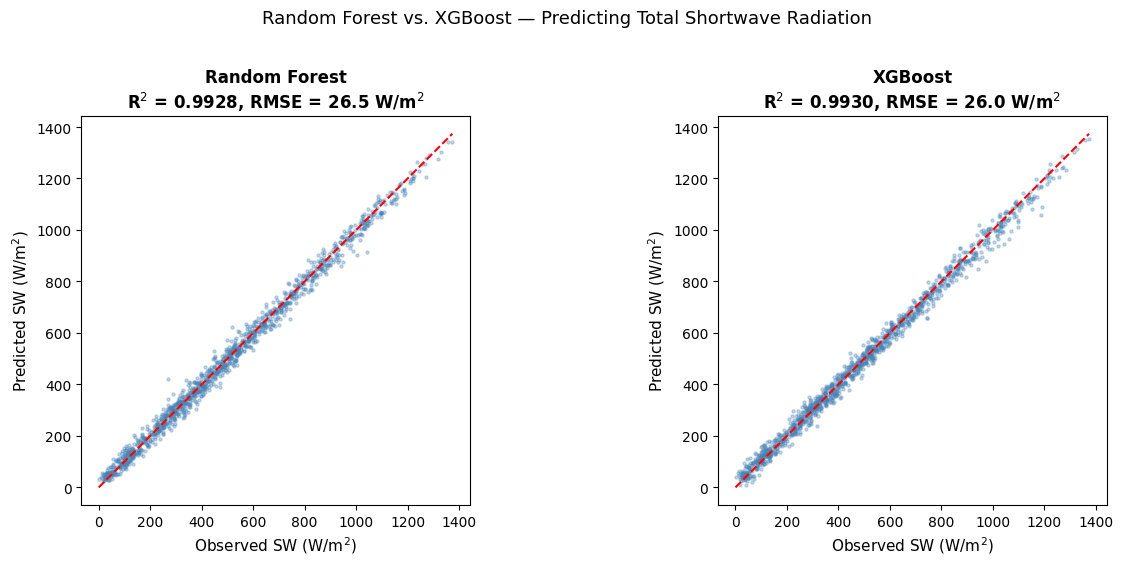

In [ ]:
# ── Side-by-side 1:1 plots ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, name, model in zip(axes, ['Random Forest', 'XGBoost'], [rf, xgb_model]):
    y_pred = model.predict(X_test)
    r2 = r2_score(yt_test, y_pred)
    rmse = np.sqrt(mean_squared_error(yt_test, y_pred))

    ax.scatter(yt_test, y_pred, s=5, alpha=0.3, color='steelblue')
    mx = max(yt_test.max(), y_pred.max())
    ax.plot([0, mx], [0, mx], 'r--', linewidth=1.5)
    ax.set_xlabel('Observed SW (W/m$^2$)', fontsize=11)
    ax.set_ylabel('Predicted SW (W/m$^2$)', fontsize=11)
    ax.set_title(f'{name}\nR$^2$ = {r2:.4f}, RMSE = {rmse:.1f} W/m$^2$',
                 fontsize=12, fontweight='bold')
    ax.set_aspect('equal')

plt.suptitle('Random Forest vs. XGBoost — Predicting Total Shortwave Radiation',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Both models produce excellent predictions. XGBoost may have a slightly lower RMSE, but the difference is often small on well-behaved tabular data. The real power of comparing both is that if they agree, you can be more confident in the result.

Now let's examine **why** these models make the predictions they do.


## 5. Feature Importance: Three Methods

Understanding *which variables drive predictions* is often more valuable than the predictions themselves. In environmental science, we don't just want to predict SW — we want to understand what atmospheric conditions control it.

Tree-based models offer three increasingly sophisticated ways to measure feature importance:

### Method 1: Gini / Impurity-Based Importance (MDI)

**How it works:** For each feature, sum the total **reduction in impurity** (Gini for classification, variance for regression) across all splits that use that feature, across all trees. Features that frequently produce high-quality splits get high importance.

**Strengths:**
- Fast to compute (comes for free with the trained model).
- Available as `model.feature_importances_` in sklearn and XGBoost.

**Weaknesses:**
- **Biased toward high-cardinality features** — a continuous feature with many unique values has more possible split points than a binary feature, giving it an unfair advantage.
- **Biased toward features used in many splits** — a feature can appear important simply because it's used often, even if each individual split provides minimal improvement.
- **Doesn't account for interactions** — tells you a feature is important but not *how* it affects the prediction.

### Method 2: Permutation Importance

**How it works:** After the model is trained, **randomly shuffle** one feature at a time and measure how much the model's accuracy (or $R^2$) drops. If shuffling a feature causes a big drop, the model relies heavily on it. If accuracy barely changes, the feature is unimportant.

**Strengths:**
- **Model-agnostic** — works with any model, not just trees.
- **Uses the test set** — measures importance for *generalization*, not just training.
- **Not biased** by feature cardinality.

**Weaknesses:**
- Slower (requires re-evaluating the model once per feature per shuffle repeat).
- **Correlated features** can confuse it — if two features are highly correlated and you shuffle one, the model can still use the other. Both features may appear less important than they truly are.

### Method 3: SHAP (SHapley Additive exPlanations)

**How it works:** Based on **Shapley values** from cooperative game theory. For each individual prediction, SHAP computes the contribution of each feature to the difference between that prediction and the average prediction.

Think of it this way: a group of players (features) collaboratively determine an outcome (the prediction). SHAP asks: "If we add features one at a time in every possible order, how much does each feature change the prediction on average?" This gives a **fair allocation** of credit to each feature.

**Strengths:**
- The **gold standard** for model interpretability.
- Provides **per-sample** explanations (not just global rankings).
- Shows the **direction** of each feature's effect (positive or negative).
- Handles **interactions** between features.
- Has strong theoretical guarantees (uniqueness, consistency, additivity).

**Weaknesses:**
- Computationally expensive for large datasets (though tree-specific algorithms are fast).
- Requires installing the `shap` library.

### Comparison summary

| Method | Speed | Bias | Per-sample? | Direction? | Model-agnostic? |
|---|---|---|---|---|---|
| Gini (MDI) | Very fast | High-cardinality bias | No | No | No (trees only) |
| Permutation | Moderate | Correlation issues | No | No | Yes |
| SHAP | Slow (fast for trees) | Minimal | **Yes** | **Yes** | Yes |


## 6. Method 1: Gini / Impurity-Based Importance


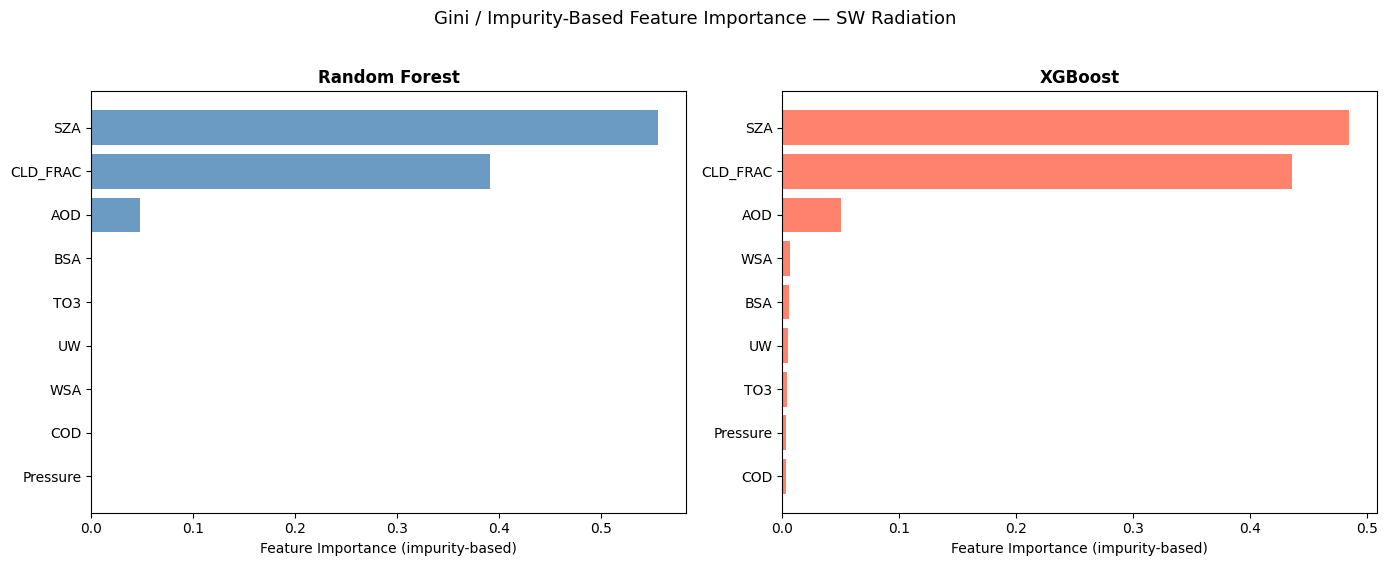

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Gini importance from both models ──
rf_imp = rf.feature_importances_
xgb_imp = xgb_model.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, imp, name, color in zip(axes,
                                 [rf_imp, xgb_imp],
                                 ['Random Forest', 'XGBoost'],
                                 ['steelblue', 'tomato']):
    sorted_idx = np.argsort(imp)
    ax.barh(range(len(sorted_idx)), imp[sorted_idx], color=color, alpha=0.8)
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels(np.array(feature_cols)[sorted_idx])
    ax.set_xlabel('Feature Importance (impurity-based)')
    ax.set_title(f'{name}', fontweight='bold', fontsize=12)

plt.suptitle('Gini / Impurity-Based Feature Importance — SW Radiation',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Both models agree that **SZA** (solar zenith angle) is the dominant predictor of total shortwave radiation, followed by **CLD_FRAC** (cloud fraction) and **AOD** (aerosol optical depth). This is physically correct: the sun angle controls the baseline radiation, clouds block it, and aerosols attenuate it.

But Gini importance only tells us *how much* each feature matters — not *how* it affects the prediction. Does higher AOD increase or decrease SW? We can't tell from these bar charts. For that, we need SHAP.


## 7. Method 2: Permutation Importance


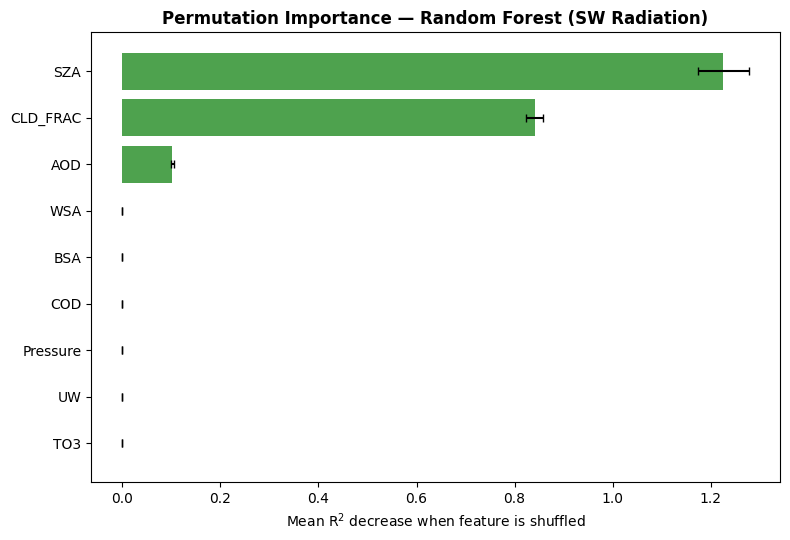

Permutation importance (mean R2 decrease):
  SZA         : 1.2263 +/- 0.0514
  CLD_FRAC    : 0.8414 +/- 0.0175
  AOD         : 0.1021 +/- 0.0034
  WSA         : 0.0000 +/- 0.0000
  BSA         : 0.0000 +/- 0.0000
  COD         : 0.0000 +/- 0.0000
  Pressure    : -0.0000 +/- 0.0000
  UW          : -0.0000 +/- 0.0000
  TO3         : -0.0000 +/- 0.0000


In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

# ── Permutation importance for Random Forest ──
perm_result = permutation_importance(
    rf, X_test, yt_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='r2'
)

perm_imp = perm_result.importances_mean
perm_std = perm_result.importances_std
sorted_idx = np.argsort(perm_imp)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(range(len(sorted_idx)), perm_imp[sorted_idx], color='forestgreen', alpha=0.8,
        xerr=perm_std[sorted_idx], capsize=3)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels(np.array(feature_cols)[sorted_idx])
ax.set_xlabel('Mean R$^2$ decrease when feature is shuffled')
ax.set_title('Permutation Importance — Random Forest (SW Radiation)', fontweight='bold')
plt.tight_layout()
plt.show()

print("Permutation importance (mean R2 decrease):")
for idx in np.argsort(perm_imp)[::-1]:
    print(f"  {feature_cols[idx]:12s}: {perm_imp[idx]:.4f} +/- {perm_std[idx]:.4f}")


The error bars show variability across 10 random shuffles. Features with large bars are less reliably measured — you might need more repeats.

**Key observation:** Permutation importance generally agrees with Gini importance on the top features (SZA, CLD_FRAC, AOD), but the relative rankings of mid-importance features may differ. This is because Gini importance reflects training-time behavior while permutation importance reflects test-time behavior.

Features with near-zero permutation importance (TO3, Pressure, BSA, WSA) contribute almost nothing to the prediction — shuffling them doesn't hurt. These could potentially be removed to simplify the model.


## 8. SHAP: The Gold Standard for Model Interpretability

### What SHAP values mean

For each individual prediction, SHAP answers the question: **"How did each feature push this prediction away from the average?"**

The average prediction across the whole dataset is the **baseline**. For each sample, SHAP decomposes the difference between its prediction and the baseline into contributions from each feature:

$$
\hat{y}_i = \phi_0 + \phi_1^{(i)} + \phi_2^{(i)} + \ldots + \phi_M^{(i)}
$$

where:
- $\phi_0$ is the baseline (average prediction)
- $\phi_j^{(i)}$ is the SHAP value for feature $j$ for sample $i$

If $\phi_{\text{SZA}}^{(i)} = -150$, that means SZA pushed sample $i$'s prediction **150 W/m$^2$ below the average**. If $\phi_{\text{CLD\_FRAC}}^{(i)} = +30$, cloud fraction pushed it 30 W/m$^2$ **above average**.

The SHAP values for all features **sum exactly** to the difference between the prediction and the baseline:

$$
\hat{y}_i - \phi_0 = \sum_{j=1}^{M} \phi_j^{(i)}
$$

This additive property is what makes SHAP so powerful — the contributions are a complete, non-overlapping decomposition of each prediction.

### The Shapley value analogy: fair credit in a team

Imagine a team of 9 atmospheric scientists collaborates on a paper. The paper gets published in *Nature*. How do you fairly distribute credit among the 9 contributors?

One approach: for every possible subset of the team, ask "How much better did the paper get when this person joined?" Average this across all possible subsets. The result is the **Shapley value** — a mathematically provable fair allocation.

SHAP does the same for features: for every possible subset of features, it asks "How much did the prediction change when this feature was added?" The average across all subsets is the SHAP value for that feature.


## 9. Computing SHAP Values


In [ ]:
# !pip install shap -q
import shap
import numpy as np

# ── Compute SHAP values for the XGBoost model ──
# TreeExplainer is optimized for tree-based models (very fast)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"  = ({shap_values.shape[0]} test samples, {shap_values.shape[1]} features)")
print(f"\nEach row is one prediction; each column is one feature's contribution.")
print(f"\nExample — first test sample:")
print(f"  Baseline (average prediction): {explainer.expected_value:.1f} W/m2")
print(f"  Model prediction:              {xgb_model.predict(X_test[:1])[0]:.1f} W/m2")
print(f"  Sum of SHAP values:            {shap_values[0].sum():.1f}")
print(f"  Baseline + SHAP sum:           {explainer.expected_value + shap_values[0].sum():.1f} W/m2")
print(f"\n  (These should match — the SHAP decomposition is exact.)")


SHAP values shape: (1250, 9)
  = (1250 test samples, 9 features)

Each row is one prediction; each column is one feature's contribution.

Example — first test sample:
  Baseline (average prediction): 496.6 W/m2
  Model prediction:              456.9 W/m2
  Sum of SHAP values:            -39.6
  Baseline + SHAP sum:           456.9 W/m2

  (These should match — the SHAP decomposition is exact.)


Notice that `baseline + sum of SHAP values = prediction` exactly. This is the fundamental SHAP property — the decomposition is complete and additive.

Now let's learn to read the four main SHAP visualizations.


## 10. How to Read SHAP Plots

SHAP provides several visualization types, each revealing different aspects of the model. Let's go through them one by one.

### Plot 1: SHAP Summary Plot (Beeswarm Plot)

This is the most important SHAP plot. It shows the SHAP value distribution for every feature:

- **Each dot** is one test sample.
- **Horizontal position** = SHAP value (how much that feature pushed the prediction up or down for that sample). Left of center = pushed prediction down; right of center = pushed it up.
- **Color** = the actual feature value for that sample (red = high, blue = low).
- **Features are sorted** by overall importance (most important at top).


/tmp/ipykernel_5660/528245506.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_df, show=False, plot_size=None)


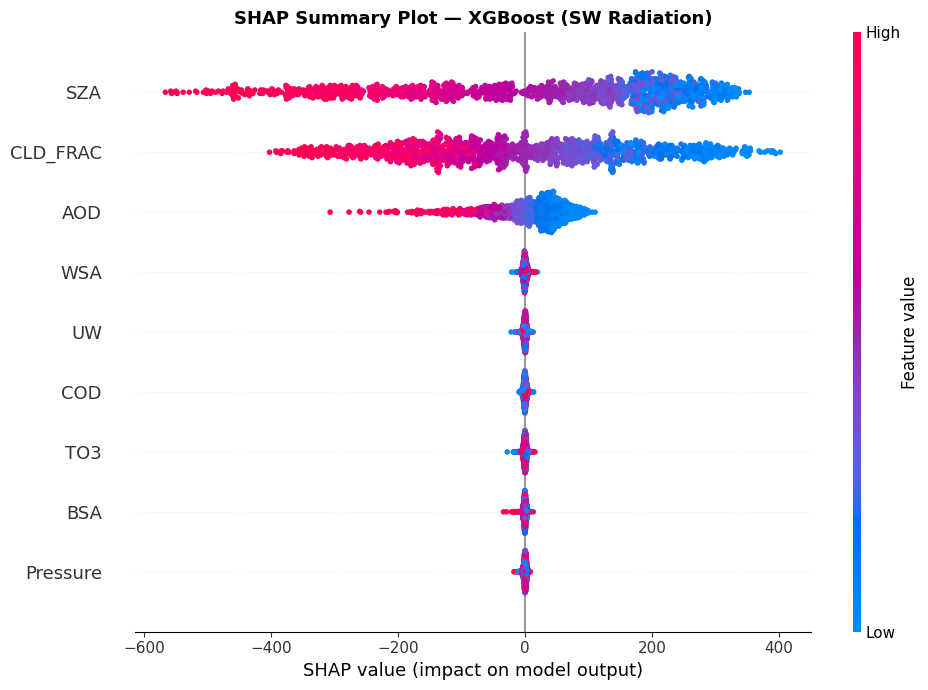

In [ ]:
# ── SHAP Summary Plot (Beeswarm) ──
# Create a DataFrame for nicer feature labels
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_df, show=False, plot_size=None)
plt.title('SHAP Summary Plot — XGBoost (SW Radiation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### How to read the beeswarm plot

Let me walk you through each feature:

**SZA (Solar Zenith Angle):**
- Red dots (high SZA = sun near horizon) cluster on the **left** (negative SHAP) → high SZA **decreases** the predicted SW. This makes physical sense: when the sun is low, less radiation reaches the surface.
- Blue dots (low SZA = sun high in sky) cluster on the **right** (positive SHAP) → low SZA **increases** predicted SW.
- The wide spread means SZA has a large impact on individual predictions.

**CLD_FRAC (Cloud Fraction):**
- Red dots (high cloud fraction) push predictions **down** (left) → more clouds = less SW.
- Blue dots (low cloud fraction) push predictions **up** (right) → clear skies = more SW.

**AOD (Aerosol Optical Depth):**
- Red dots (high AOD = hazy) push predictions **down** → aerosols attenuate radiation.
- Blue dots (low AOD = clean air) push predictions **up**.

**Features at the bottom** (TO3, Pressure, BSA, WSA) have SHAP values clustered near zero — they barely affect individual predictions.

> **The beeswarm plot answers questions that bar charts can't:** "Does higher AOD increase or decrease SW?" (decrease). "Is the effect of SZA symmetric?" (look at the distribution). "Are there outlier samples where a usually-unimportant feature matters?" (look for scattered dots).


### Plot 2: SHAP Bar Plot (Global Importance)

If you just want a ranking of overall feature importance (like Gini importance but based on SHAP):


/tmp/ipykernel_5660/546578122.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False, plot_size=None)


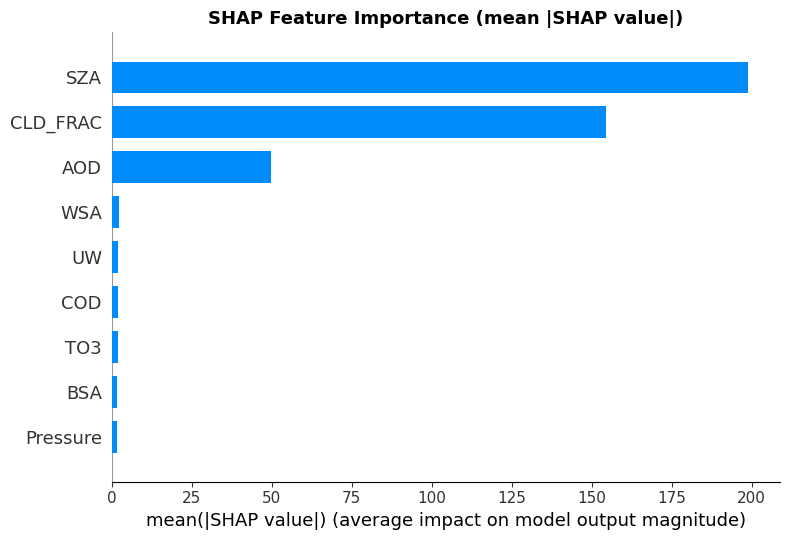

In [ ]:
# ── SHAP Bar Plot ──
fig, ax = plt.subplots(figsize=(8, 5.5))
shap.summary_plot(shap_values, X_test_df, plot_type='bar', show=False, plot_size=None)
plt.title('SHAP Feature Importance (mean |SHAP value|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The bar plot shows the **mean absolute SHAP value** for each feature — the average magnitude of each feature's contribution across all test samples. This is a global importance ranking, similar to Gini importance, but without the cardinality bias.


### Plot 3: SHAP Dependence Plot

The dependence plot shows *how* a single feature affects the prediction — it's like a partial dependence plot but richer:

- **x-axis:** the feature value.
- **y-axis:** the SHAP value (that feature's contribution to the prediction).
- **Color:** automatically chosen to show the feature with the strongest interaction.


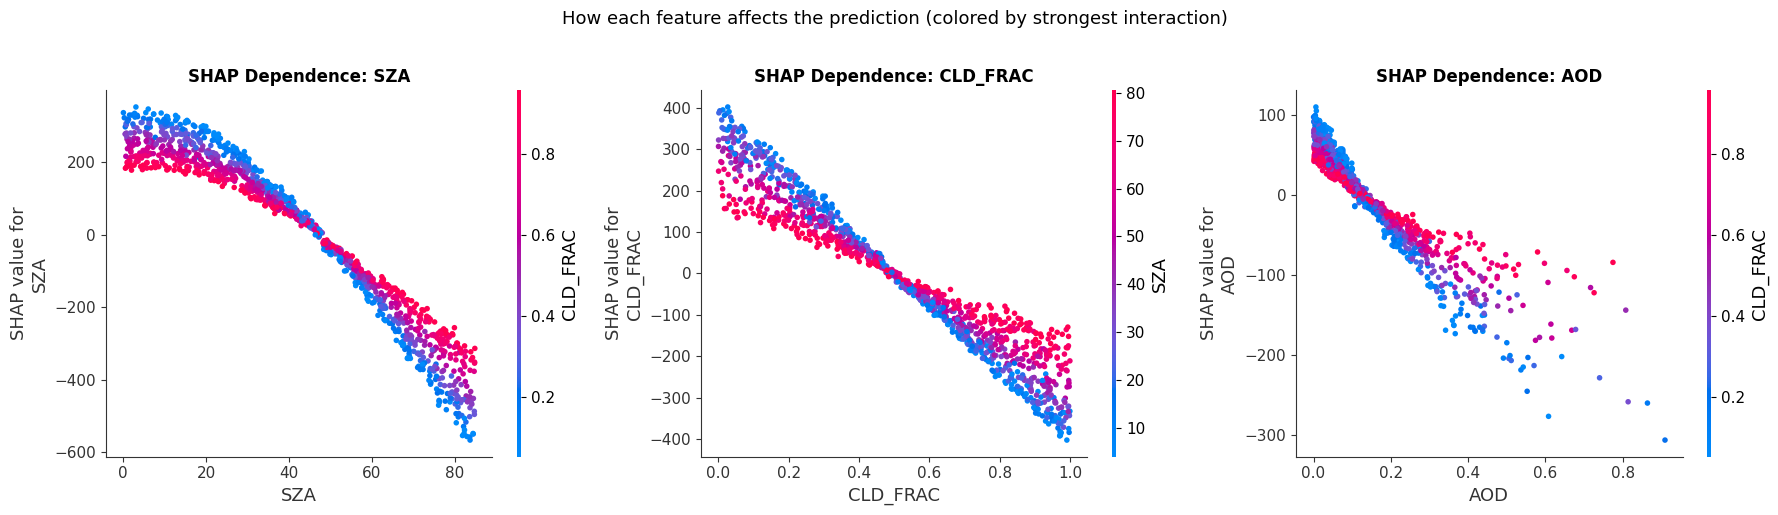

In [ ]:
# ── SHAP Dependence Plots for the top 3 features ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, ['SZA', 'CLD_FRAC', 'AOD']):
    shap.dependence_plot(feat, shap_values, X_test_df, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.suptitle('How each feature affects the prediction (colored by strongest interaction)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Reading the dependence plots

**SZA dependence plot:**
- Clear **nonlinear** relationship: SHAP value is positive (increases SW prediction) when SZA is low (sun high in sky) and negative when SZA is high (sun near horizon).
- The transition is not linear — it follows a cosine-like curve, which is exactly the physical relationship between solar angle and incoming radiation.
- The **color** (representing the interaction feature) may show that at the same SZA, samples with high cloud fraction have lower SHAP values — indicating an interaction between SZA and clouds.

**CLD_FRAC dependence plot:**
- Negative slope: higher cloud fraction → lower SHAP value → lower predicted SW.
- The spread at each cloud fraction value reflects interactions with other variables (SZA, AOD).

**AOD dependence plot:**
- Negative relationship: higher aerosol loading → lower predicted SW.
- The effect is strongest for low-SZA (high-sun) conditions, where there's more direct beam to attenuate.

> **Key insight:** Dependence plots reveal **nonlinearities and interactions** that bar charts and importance rankings hide. A feature might be globally "important" but its effect could be nonlinear, saturating, or threshold-based — and the dependence plot shows this.


## 11. SHAP Analysis: Direct vs. Diffuse Radiation

The real scientific insight comes from comparing SHAP explanations for different targets. Let's train XGBoost separately for SW_direct and SW_diffuse and compare what drives each component.


In [ ]:
# ── Train separate XGBoost models for direct and diffuse ──
xgb_direct = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=42, n_jobs=-1)
xgb_direct.fit(X_train, yd_train, eval_set=[(X_test, yd_test)], verbose=False)

xgb_diffuse = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1,
                                 subsample=0.8, colsample_bytree=0.8,
                                 random_state=42, n_jobs=-1)
xgb_diffuse.fit(X_train, yf_train, eval_set=[(X_test, yf_test)], verbose=False)

print(f"SW_direct  — Test R2: {r2_score(yd_test, xgb_direct.predict(X_test)):.4f}")
print(f"SW_diffuse — Test R2: {r2_score(yf_test, xgb_diffuse.predict(X_test)):.4f}")

# ── SHAP values for both ──
shap_direct = shap.TreeExplainer(xgb_direct).shap_values(X_test)
shap_diffuse = shap.TreeExplainer(xgb_diffuse).shap_values(X_test)


SW_direct  — Test R2: 0.9939
SW_diffuse — Test R2: 0.9309


/tmp/ipykernel_5660/546268706.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_direct, X_test_df, show=False, plot_size=None)
/tmp/ipykernel_5660/546268706.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_diffuse, X_test_df, show=False, plot_size=None)


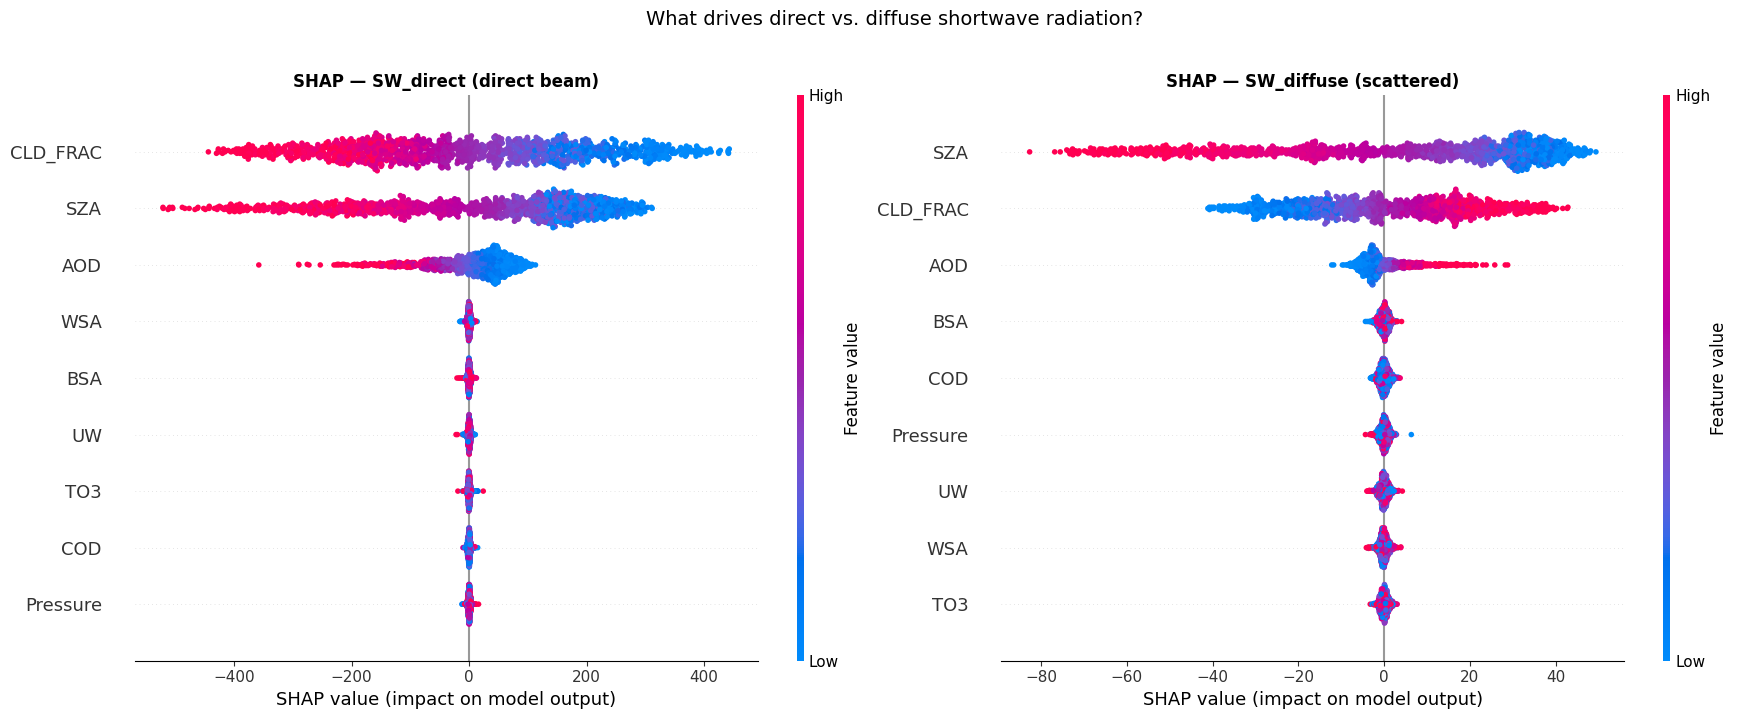

In [ ]:
# ── Side-by-side SHAP summary plots ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_direct, X_test_df, show=False, plot_size=None)
axes[0].set_title('SHAP — SW_direct (direct beam)', fontweight='bold', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(shap_diffuse, X_test_df, show=False, plot_size=None)
axes[1].set_title('SHAP — SW_diffuse (scattered)', fontweight='bold', fontsize=12)

plt.suptitle('What drives direct vs. diffuse shortwave radiation?',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Physical interpretation

Comparing the two beeswarm plots reveals the atmospheric physics:

**SW_direct (direct beam from the sun):**
- **SZA** dominates — the cosine of SZA directly controls the direct beam geometry.
- **CLD_FRAC** is second — clouds block the direct beam. High CLD_FRAC → strong negative SHAP.
- **AOD** is third — aerosols scatter the direct beam out of the solar path (Beer-Lambert extinction).

**SW_diffuse (radiation scattered by atmosphere and clouds):**
- **SZA** still matters (controls total available solar energy).
- **CLD_FRAC** has a more complex effect — moderate clouds *increase* diffuse radiation (by scattering direct beam into all directions), but very thick clouds decrease it (block everything). You may see red dots (high CLD_FRAC) on *both* sides of zero.
- **AOD** contributes positively — aerosols scatter direct beam into diffuse radiation, so more aerosols can actually *increase* diffuse SW.
- **COD** (cloud optical depth) is more important for diffuse than direct — it determines how much scattering the cloud layer produces.

This is a beautiful example of **how SHAP reveals physics from data**. The model learned the physically correct relationships between atmospheric state variables and radiation components without being told any radiative transfer equations. SHAP lets us verify that the learned relationships match our physical understanding.


## 12. Grand Comparison: All Algorithms on SW Radiation

Let's benchmark every regression method from the course on this dataset:


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import time

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

regressors = [
    ("Linear Regression",  LinearRegression(), X_train_sc, X_test_sc),
    ("KNN (k=10)",         KNeighborsRegressor(10), X_train_sc, X_test_sc),
    ("SVR (RBF)",          SVR(kernel='rbf', C=100), X_train_sc, X_test_sc),
    ("Decision Tree (d=10)", DecisionTreeRegressor(max_depth=10, random_state=42), X_train, X_test),
    ("Random Forest",      RandomForestRegressor(200, random_state=42, n_jobs=-1), X_train, X_test),
    ("XGBoost",            xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.1,
                                             random_state=42, n_jobs=-1), X_train, X_test),
]

results = []
print(f"{'Model':<22s}  {'Test R2':>10s}  {'RMSE':>10s}  {'Time (s)':>10s}  {'Scaling':>8s}")
print("-" * 66)

for name, model, Xtr, Xte in regressors:
    t0 = time.time()
    model.fit(Xtr, yt_train)
    tt = time.time() - t0
    y_pred = model.predict(Xte)
    r2 = r2_score(yt_test, y_pred)
    rmse = np.sqrt(mean_squared_error(yt_test, y_pred))
    scaling = "Yes" if "Linear" in name or "KNN" in name or "SVR" in name else "No"
    results.append((name, r2, rmse, tt))
    print(f"{name:<22s}  {r2:>10.4f}  {rmse:>10.1f}  {tt:>10.3f}  {scaling:>8s}")


Model                      Test R2        RMSE    Time (s)   Scaling
------------------------------------------------------------------
Linear Regression           0.8790       108.5       0.023       Yes
KNN (k=10)                  0.9161        90.3       0.009       Yes
SVR (RBF)                   0.9906        30.2       1.555       Yes
Decision Tree (d=10)        0.9809        43.1       0.057        No
Random Forest               0.9928        26.5       8.736        No
XGBoost                     0.9946        22.9       2.216        No


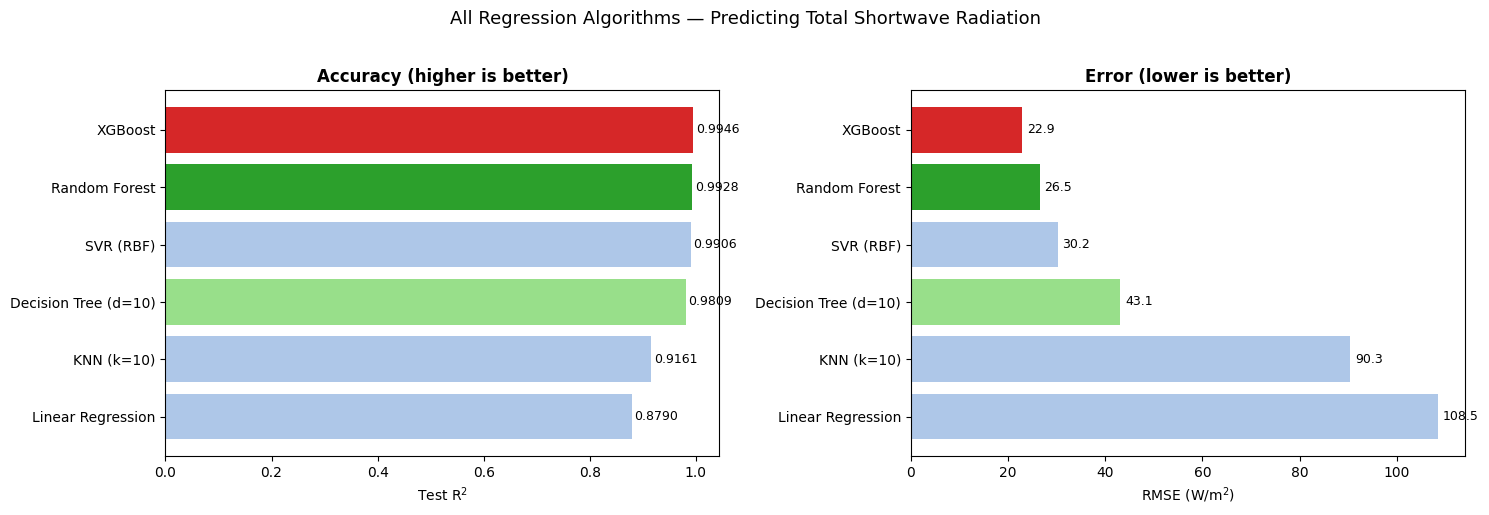

In [ ]:
# ── Visualization ──
import matplotlib.pyplot as plt
import numpy as np

names = [r[0] for r in results]
r2s = [r[1] for r in results]
rmses = [r[2] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sorted_idx = np.argsort(r2s)
colors = ['#aec7e8','#aec7e8','#aec7e8','#98df8a','#2ca02c','#d62728']

axes[0].barh([names[i] for i in sorted_idx], [r2s[i] for i in sorted_idx],
             color=[colors[i] for i in sorted_idx])
axes[0].set_xlabel('Test R$^2$')
axes[0].set_title('Accuracy (higher is better)', fontweight='bold')
for i, idx_val in enumerate(sorted_idx):
    axes[0].text(r2s[idx_val] + 0.005, i, f'{r2s[idx_val]:.4f}', va='center', fontsize=9)

sorted_rmse_idx = np.argsort(rmses)[::-1]
axes[1].barh([names[i] for i in sorted_rmse_idx], [rmses[i] for i in sorted_rmse_idx],
             color=[colors[i] for i in sorted_rmse_idx])
axes[1].set_xlabel('RMSE (W/m$^2$)')
axes[1].set_title('Error (lower is better)', fontweight='bold')
for i, idx_val in enumerate(sorted_rmse_idx):
    axes[1].text(rmses[idx_val] + 1, i, f'{rmses[idx_val]:.1f}', va='center', fontsize=9)

plt.suptitle('All Regression Algorithms — Predicting Total Shortwave Radiation',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Choosing the right algorithm

| Situation | Recommendation |
|---|---|
| Quick baseline | Linear Regression |
| Best accuracy, moderate data | **Random Forest** or **XGBoost** |
| Need to understand feature effects | XGBoost + SHAP |
| Very large dataset (>100K) | XGBoost (efficient) or Random Forest (parallelizable) |
| Need probability calibration | Ensemble methods with calibration |
| Physical interpretability matters | SHAP on any tree-based model |


## 13. Summary

| Concept | Key takeaway |
|---|---|
| Bagging (Random Forest) | Independent trees on bootstrap samples; reduces variance |
| Boosting (XGBoost) | Sequential trees correcting residuals; reduces bias |
| Learning rate ($\eta$) | Controls step size; small = conservative, needs more rounds |
| Early stopping | Stop boosting when validation loss stops improving |
| Gini importance | Fast but biased toward high-cardinality features |
| Permutation importance | Model-agnostic; measures actual accuracy drop when feature is shuffled |
| SHAP values | Per-sample decomposition of predictions; gold standard for interpretability |
| SHAP beeswarm | Shows importance, direction, and feature value for every sample |
| SHAP dependence | Reveals nonlinear effects and interactions |
| SW radiation results | SZA dominates total SW; CLD_FRAC and AOD drive direct beam; CLD_FRAC and COD drive diffuse |

### Complete algorithm reference (Lectures 14-21)

| Lecture | Algorithm | Best for |
|---|---|---|
| 14 | Linear / Logistic regression | Simple baselines, interpretability |
| 15 | SVM | Small datasets, kernel nonlinearity |
| 16 | Naive Bayes | Fast baseline, text/count data |
| 17 | KNN | Simple nonparametric problems |
| 18 | K-Means | Unsupervised clustering |
| 19 | PCA | Dimensionality reduction, visualization |
| 20 | Decision Trees / Random Forests | Tabular data (the default go-to) |
| **21** | **XGBoost + SHAP** | **Highest accuracy + deep interpretability** |

### For your final projects

1. **Train Random Forest and XGBoost** — compare performance; report the better one.
2. **Run SHAP on your best model** — produce a beeswarm plot and dependence plots for the top 3 features.
3. **Interpret the SHAP results ecologically** — do the learned relationships match physical/ecological expectations?

This three-step workflow (train → explain → validate) is the professional standard for ML in environmental science.
